# Imports

In [27]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
import anndata as ad
from scipy import sparse
from anndata import AnnData
import scanpy as sc
import torch
from ciim.src.utils.util import bulkify_func
torch.set_float32_matmul_precision('medium')
from ciim.src.clock.NN.helper import get_params, test_datasets, train_datasets, format_data, save_path_train, save_path_test, cell_type_train, data_type, batch_key, plot_history, wrapper_umap

import torch
from ciim.src.common import datasets_all
import cpa


def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()
def normalize(adata):
    adata.X = adata.X.todense().A if sparse.issparse(adata.X) else adata.X
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

# ---- simple aging clock
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ciim.src.clock.helper import align_feature_space

class age_predictor:
    def __init__(self):
        self.reg = Ridge(alpha=1.0)
    def format_data(self, adata: AnnData):
        X = adata.X
        y = adata.obs["age"].values.astype(np.float32)
        group = adata.obs["donor_age"].values
        batch = adata.obs["dataset"].values
        return X, y, group, batch
    def train(self, adata):
        X, y, _, _ = self.format_data(adata)
        self.features = adata.var_names
        self.reg.fit(X, y)
    def predict(self, adata):
        adata = align_feature_space(adata, self.features)
        X, y, group, batch = self.format_data(adata)
        y_pred = self.reg.predict(X)
        adata.obs["predicted_age"] = y_pred
        self.evaluate(y_pred, y, group, batch)
        return adata

    def train_cv(self, adata):
        X, y, group, batch = self.format_data(adata)
        cv = KFold(n_splits=5, shuffle=True, random_state=0)

        y_pred_store = []
        y_true_store = []
        group_store = []
        batch_store = []

        for train_idx, test_idx in cv.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            group_test = group[test_idx]
            batch_test = batch[test_idx]

            # Standardize
            # X_train = scaler.fit_transform(X_train)
            # X_test = scaler.transform(X_test)

            self.reg.fit(X_train, y_train)
            y_pred = self.reg.predict(X_test)

            y_pred_store.append(y_pred)
            y_true_store.append(y_test)
            group_store.append(group_test)
            batch_store.append(batch_test)

        # Concatenate results
        y_pred = np.concatenate(y_pred_store)
        y_test = np.concatenate(y_true_store)
        group_all = np.concatenate(group_store)
        batch_all = np.concatenate(batch_store)
        self.evaluate(y_pred, y_test, group_all, batch_all)
    @classmethod
    def evaluate(cls, y_pred, y_test, group_all, batch_all):
        # Aggregate by group and batch
        df = pd.DataFrame({
            "y_pred": y_pred,
            "y_true": y_test,
            "group": group_all,
            "batch": batch_all
        })
        df['group'] = df['group'].astype(str)
        df['batch'] = df['batch'].astype(str)
        df_grouped = df.groupby(["group", "batch"], as_index=False).median()

        # Compute metrics
        rho, _ = spearmanr(df_grouped["y_true"], df_grouped["y_pred"])
        r2 = r2_score(df_grouped["y_true"], df_grouped["y_pred"])

        print(f"Spearman correlation (per donor): {rho:.2f}, R² (per donor): {r2:.2f}")
    
        # Plot prediction
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=df_grouped, x="y_true", y="y_pred", hue="batch", alpha=0.7)
        min_val = min(df_grouped["y_true"].min(), df_grouped["y_pred"].min())
        max_val = max(df_grouped["y_true"].max(), df_grouped["y_pred"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.xlabel("True median age (per donor)")
        plt.ylabel("Predicted median age (per donor)")
        # plt.title("Ridge regression on latent space")
        plt.legend(loc=(1, .8), frameon=False)
        # plt.tight_layout()

# EXA

In [9]:
adata_train = format_data(train_datasets, cell_type_train, data_type)

In [10]:
adata_test = format_data(test_datasets, cell_type_train, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [11]:
if data_type=='sc':
    adata_train_bulk = bulkify_func(adata_train, covariates=['cell_type', 'donor_id', 'age'])
    adata_test_bulk = bulkify_func(adata_test, covariates=['cell_type', 'donor_id', 'age'])

    adata_train_bulk = normalize(adata_train_bulk)
    adata_test_bulk = normalize(adata_test_bulk)
else:
    adata_train_bulk = adata_train
    adata_test_bulk = adata_test

Spearman correlation (per donor): 0.83, R² (per donor): 0.71
Spearman correlation (per donor): 0.80, R² (per donor): 0.33


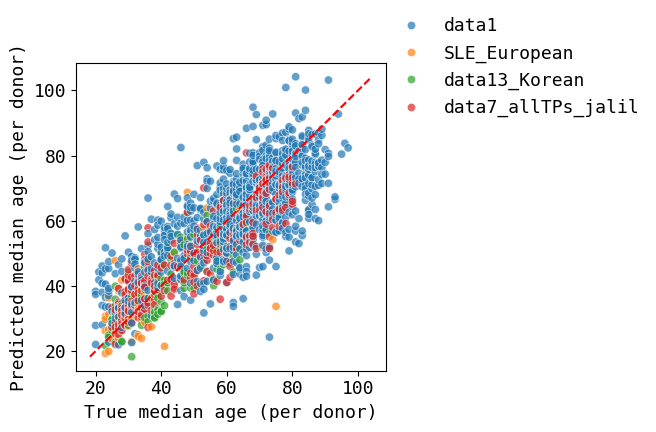

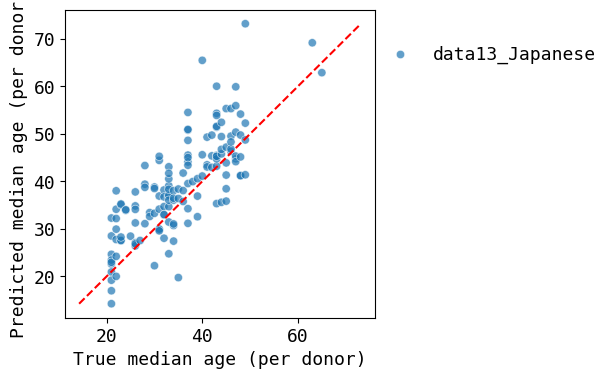

In [10]:
for cell_type in ['CD8T']:
    adata_train_bulk_t = adata_train_bulk[adata_train_bulk.obs['cell_type'] == cell_type].copy()
    adata_test_bulk_t = adata_test_bulk[adata_test_bulk.obs['cell_type'] == cell_type].copy()
    obj = age_predictor()
    obj.train_cv(adata_train_bulk_t)
    obj.train(adata_train_bulk_t)
    obj.predict(adata_test_bulk_t)

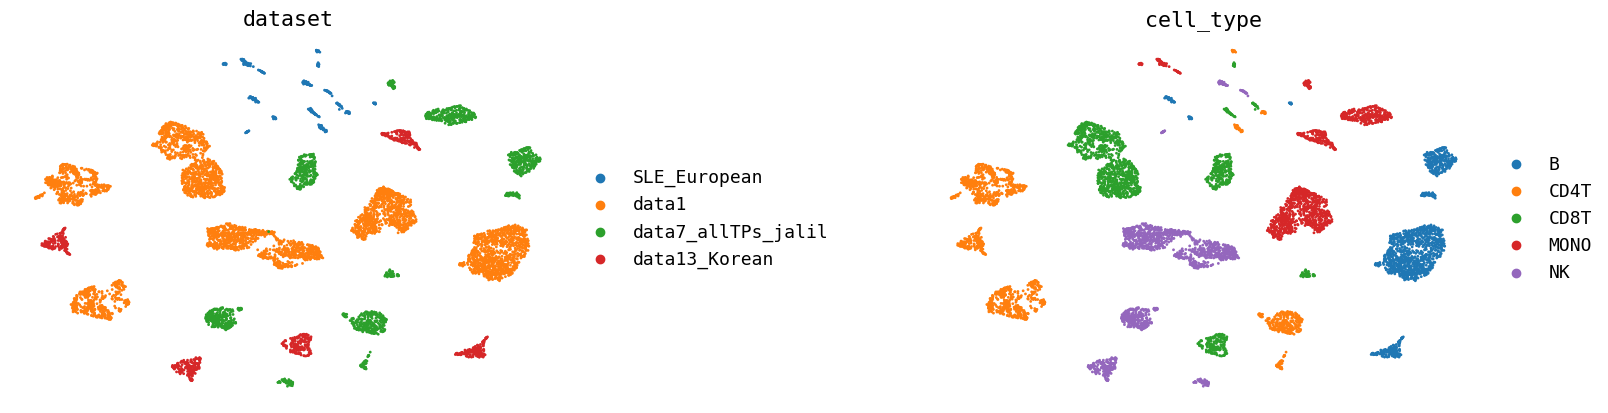

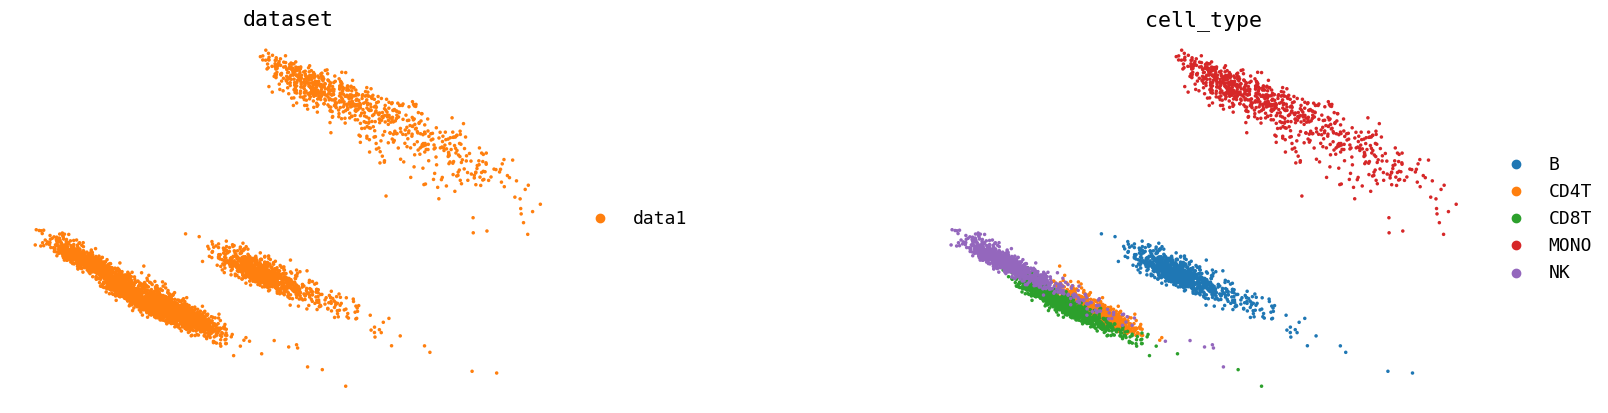

In [17]:
# - original data embedding
if True:
    adata_raw = adata_train.copy()
    if data_type=='sc':
        sc.pp.normalize_total(adata_raw)
        sc.pp.log1p(adata_raw)
    # sc.pp.highly_variable_genes(adata_raw, n_top_genes=2000, subset=True)
    sc.pp.pca(adata_raw)
    wrapper_umap(adata_raw)

    sc.pl.pca(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

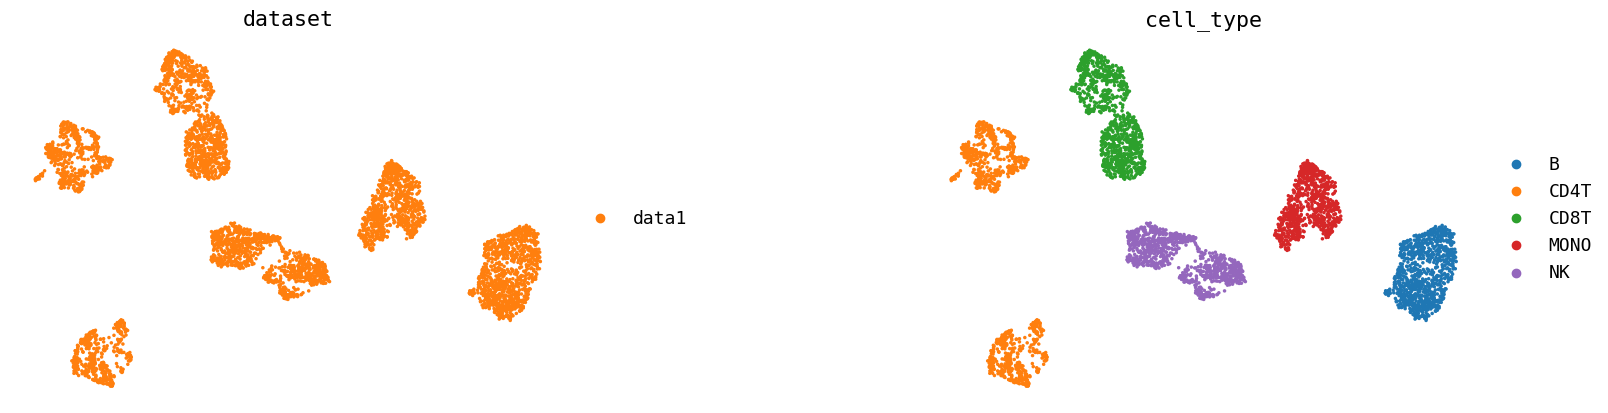

In [ ]:
sc.pl.umap(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

In [19]:
aaa

NameError: name 'aaa' is not defined

# Train

In [33]:
# run ../scripts/run_train_nn.sh

In [2]:

print("Training mode activated.")
assert len(train_datasets)>0, "Training mode requires at least one training dataset."
print('Loading training data ... ')
adata = format_data(train_datasets, cell_type_train, data_type)

Training mode activated.
Loading training data ... 


In [3]:
model_params, trainer_params = get_params(data_type)

cpa.CPA.wrapper_setup_data(adata, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train)
model = cpa.CPA(adata=adata,
                **model_params,
            )
model.train(max_epochs=400,
        use_gpu=True,
        batch_size=128 if data_type == 'sc' else 32,
        plan_kwargs=trainer_params,
        early_stopping_patience=10,
        check_val_every_n_epoch=10,
        save_path=save_path_train,
    )

[rank: 0] Global seed set to 6977


Setting up data without cell type filtering.
registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 4/400:   1%|          | 3/400 [00:20<45:08,  6.82s/it, v_num=1, recon=7.95e+3, adv_loss=0.425, age_loss=nan, acc_dataset=0.954, acc_cell_type=0.939]

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

# Evaluate on train data

-TODO: 1. train with the original version. 2. reduce the epock, 3. make it 'nb'. 4. train with larger datasets 

INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']


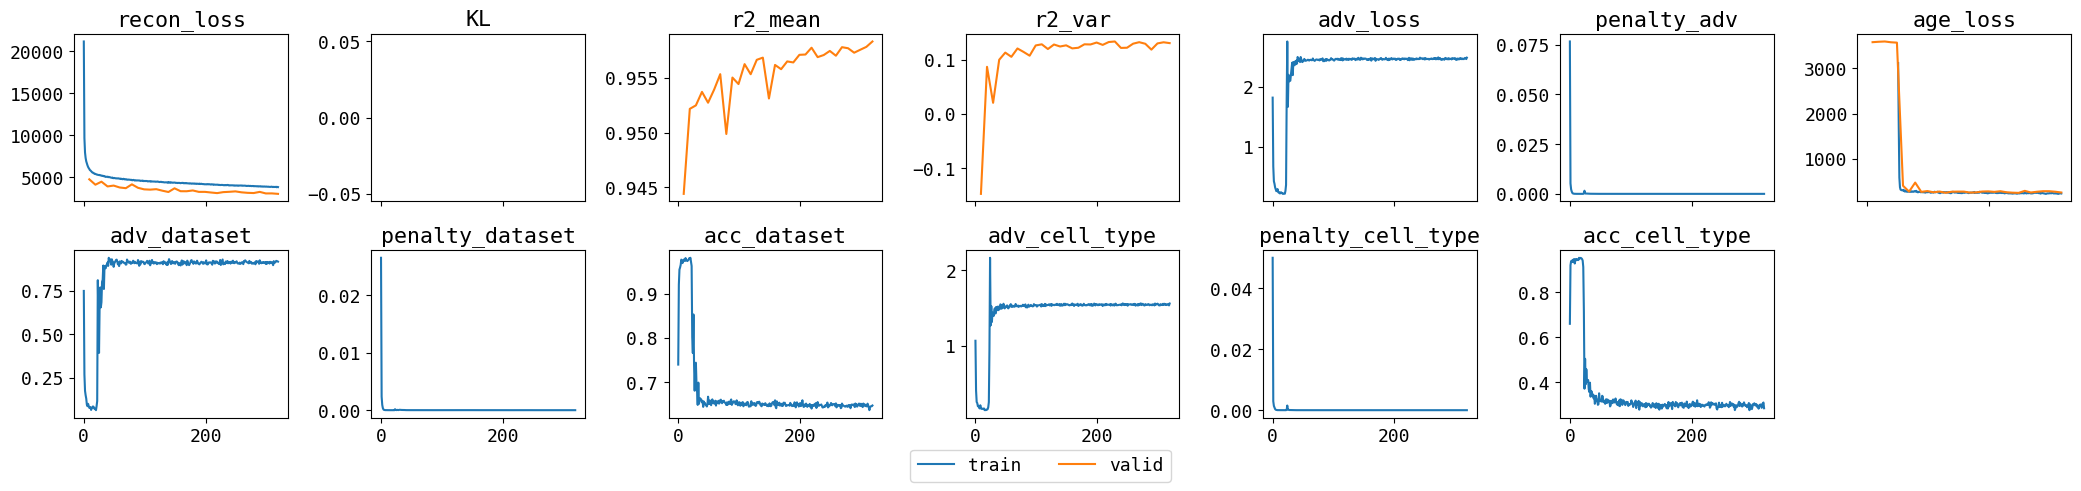

In [3]:
import cpa
from ciim.src.common import save_dir
# save_path_train=f'{save_dir}/NN/try1' # trained with cleaned cpa, zinb, ['SLE_European', 'data12', 'data13_Korean']

model = cpa.CPA.load(dir_path=save_path_train)
plot_history(model)

In [3]:
# print(model.adata_manager._registry)
# print(model.covars_encoder)

In [5]:
# adata = model.adata.copy()
adata_train = format_data(train_datasets, cell_type_train, data_type)
adata = adata_train.copy()
cpa.CPA.wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)
latent_dict = model.get_latent_representation(adata=adata)

Setting up data without cell type filtering.
registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']


100%|██████████| 234/234 [00:01<00:00, 216.28it/s]


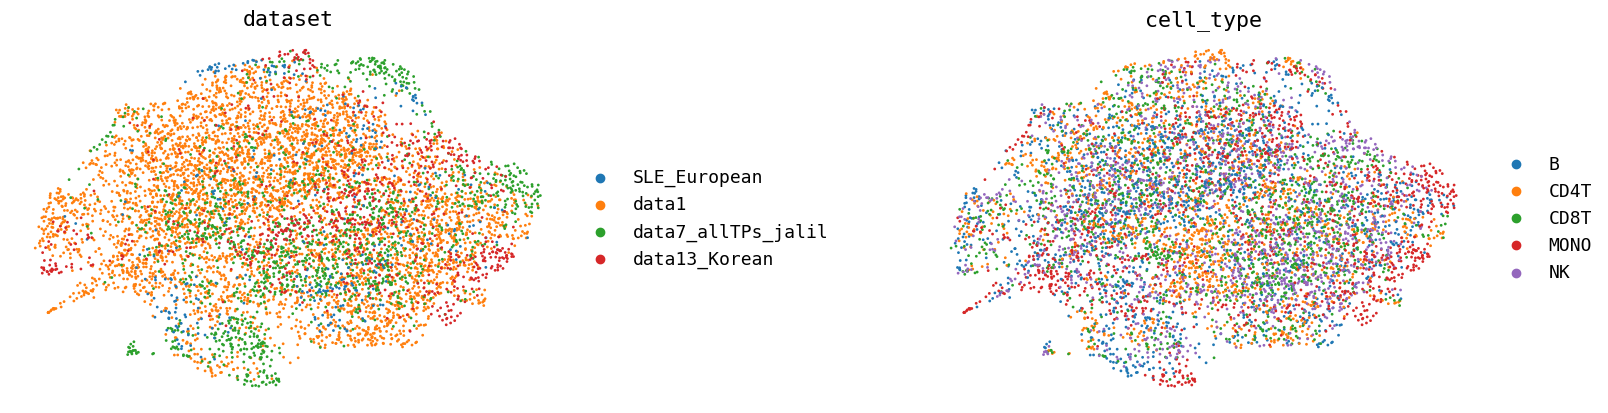

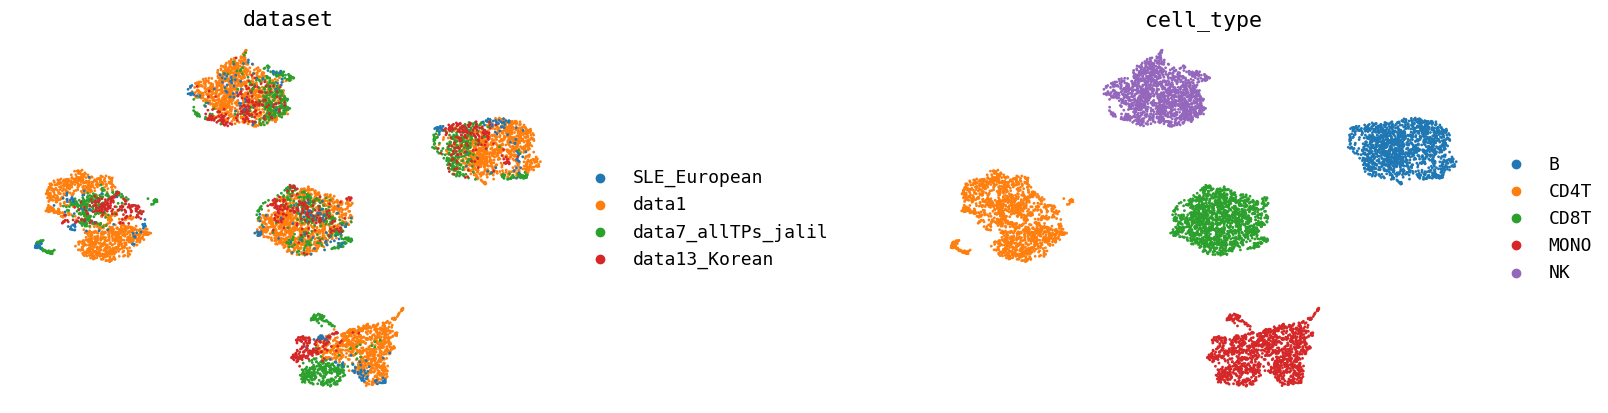

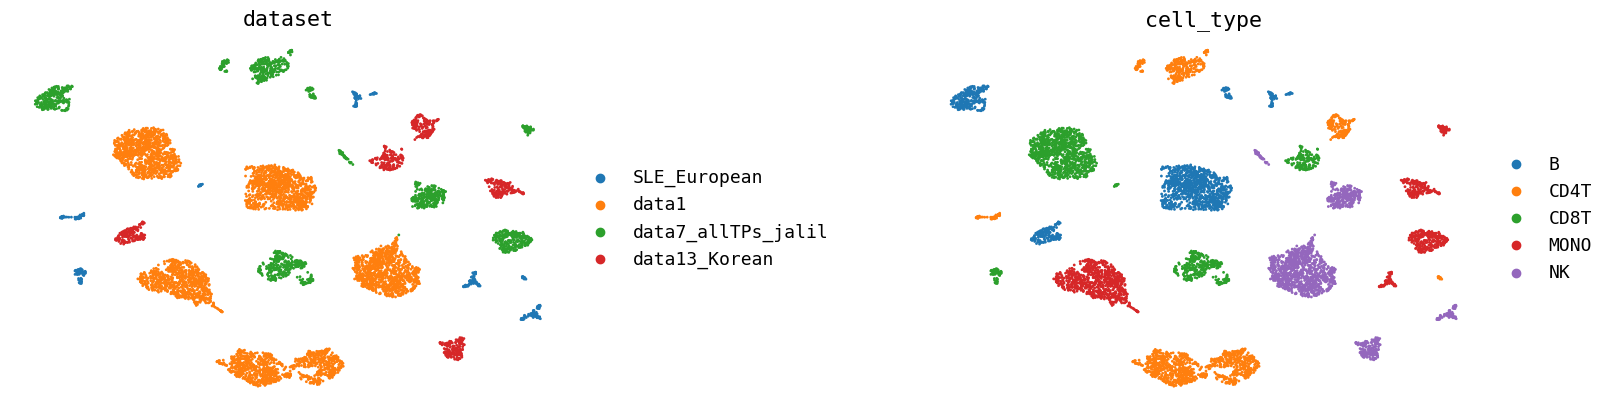

In [6]:
if True:
    wrapper_umap(latent_dict['latent_basal'])
    wrapper_umap(latent_dict['latent_corrected'])
    wrapper_umap(latent_dict['latent_after'])

In [9]:
model.predict_age(adata)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


100%|██████████| 59/59 [00:00<00:00, 118.30it/s]


Spearman correlation (per donor): 0.65, R² (per donor): 0.33


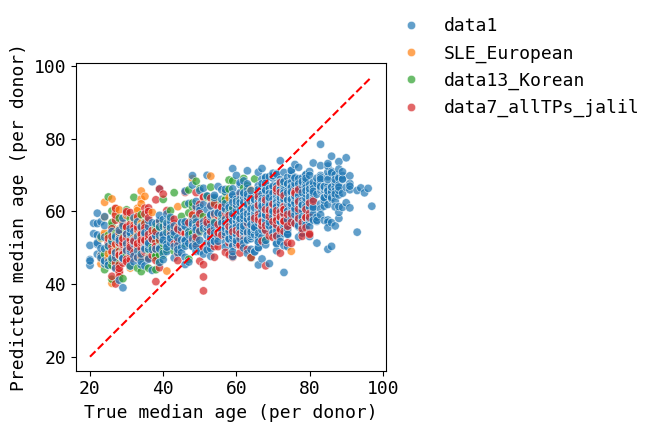

In [23]:
# adata.obs['age_predicted']
# adata_t = adata[adata.obs['cell_type'] == 'CD8T'].copy()
age_predictor.evaluate(
    y_pred=adata.obs['age_predicted'], y_test=adata.obs['age'], 
    group_all=adata.obs['donor_age'], batch_all=adata.obs['dataset'])

Spearman correlation (per donor): 0.75, R² (per donor): 0.57


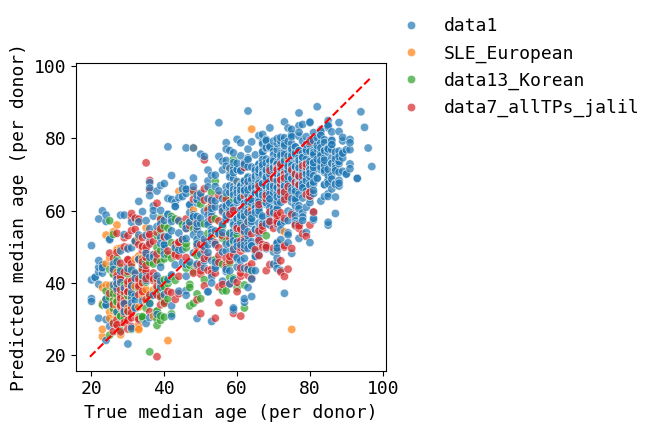

In [20]:
adata_corrected = latent_dict['latent_corrected']
if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected
for cell_type in ['CD8T']:
    adata_corrected_bulk_t = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == cell_type].copy()

    obj = age_predictor()
    obj.train_cv(adata_corrected_bulk_t)

In [7]:
# obj = age_predictor()
# obj.train(adata_corrected_bulk_t)
# obj.predict(adata_test_bulk_t)

In [8]:
aaa

NameError: name 'aaa' is not defined

# Train on test data

In [28]:
print('Loading test data ... ')
adata_test = format_data(test_datasets, cell_type_train, data_type)

Loading test data ... 


In [29]:
def integrate_test_data(model, adata_test, batch_key):
    new_batches = adata_test.obs[batch_key].unique()
    if batch_key not in model.covars_encoder:
        raise ValueError(f"Batch key '{batch_key}' not found in covariates encoder. Please ensure the batch key is correctly set.")
    existing_batches = set(model.covars_encoder[batch_key])

    # if set(new_batches).issubset(existing_batches):
    #     print(f"Batch '{new_batches}' already exists in the model. No need to extend embedding.")
    #     return

    from ciim.src.clock.helper import align_feature_space
    gene_names = model.adata.var_names
    adata_test = align_feature_space(adata_test, gene_names)
    print('Extending embedding for test dataset ... ')
    model.module.extend_embedding(covariate=batch_key, new_keys=new_batches)

    model.wrapper_setup_data(adata=adata_test, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train, initial_setup=False)
    # Freeze all other self.module parameters
    for name, param in model.module.named_parameters():
        if f'covars_embeddings.{batch_key}.weight' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    # - check trainable params
    for name, param in model.module.named_parameters():
        if param.requires_grad:
            print(f"{name}: trainable")
        else:
            # print(f"{name}: frozen (requires_grad=False)")
            pass
    return model, adata_test
import copy
print('Loading model ... ')
model = cpa.CPA.load(dir_path=save_path_train)
model, adata_test = integrate_test_data(model, adata_test, batch_key=batch_key)

Loading model ... 
INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']
Extending embedding for test dataset ... 
Setting up data without cell type filtering.
Loading settings from registry. Given batch key and covariates will be ignored.
registred datasets:  ['data12' 'data13_Japanese']
covars_embeddings.dataset.weight: trainable


In [4]:
# model.adata = adata_test

In [5]:
# model._register_manager_for_instance(
#                     model.adata_manager.transfer_fields(adata_test, extend_categories=True)
#             )
# # model.adata_manager.registry

In [6]:
# this should be added to validate_registery -> before inference. otherwise, it will crash the inference
# model.adata_manager.registry['field_registries']['dataset']['state_registry']['categorical_mapping'].tolist()

In [8]:
adata_train = format_data(train_datasets, cell_type_train, data_type)

In [30]:
adata_all = ad.concat([adata_train, adata_test])
model.wrapper_setup_data(adata=adata_all, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train, initial_setup=False)
latent_dict = model.get_latent_representation(adata=adata_all)


Setting up data without cell type filtering.
Loading settings from registry. Given batch key and covariates will be ignored.
registred datasets:  ['SLE_European' 'data1' 'data12' 'data13_Japanese' 'data13_Korean'
 'data7_allTPs_jalil']


100%|██████████| 262/262 [00:00<00:00, 300.81it/s]


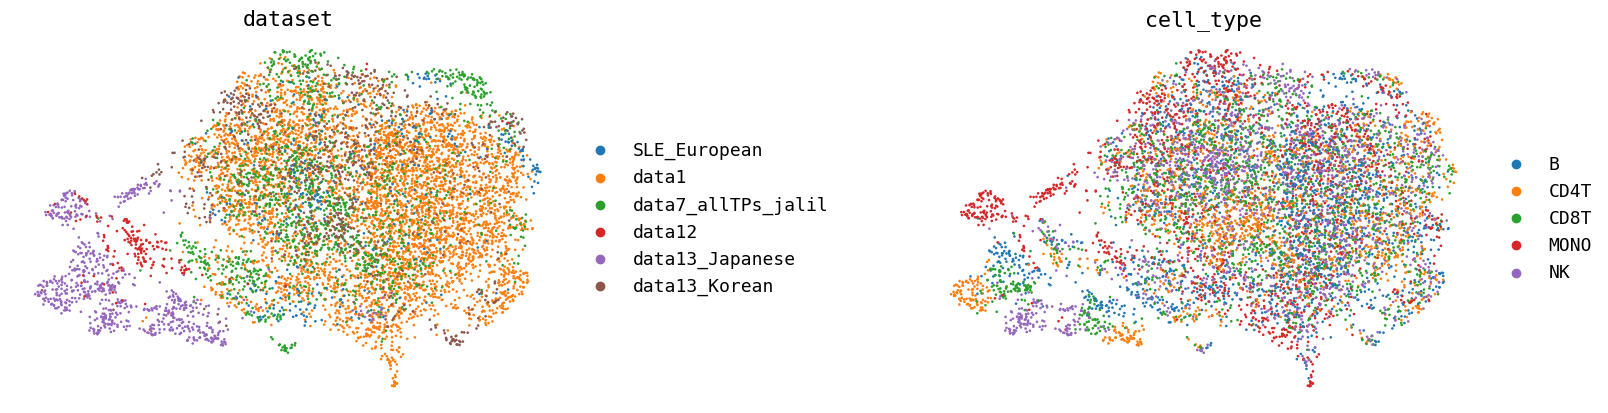

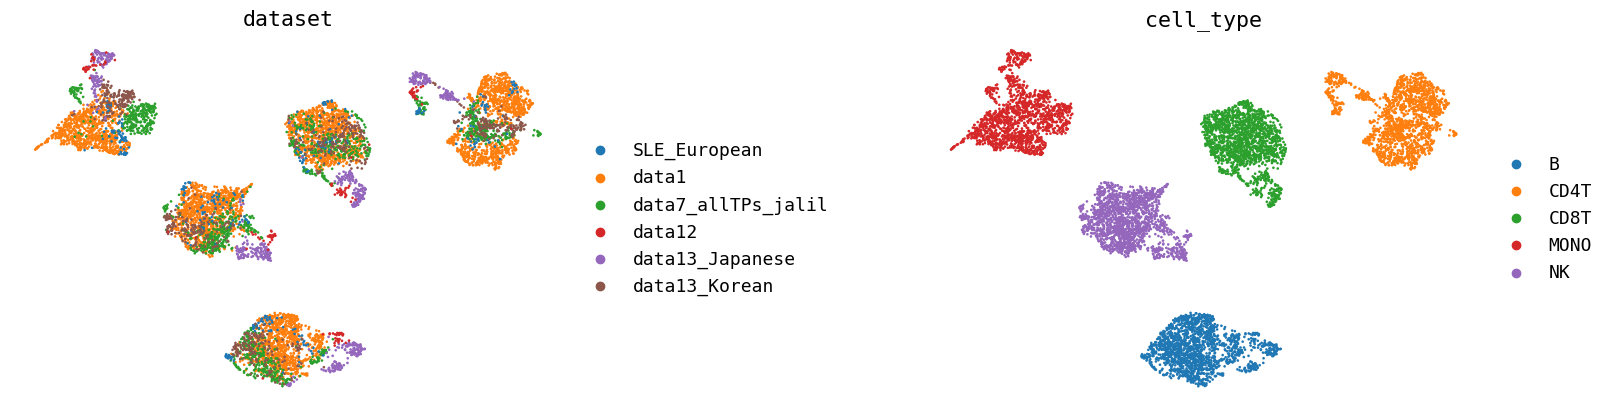

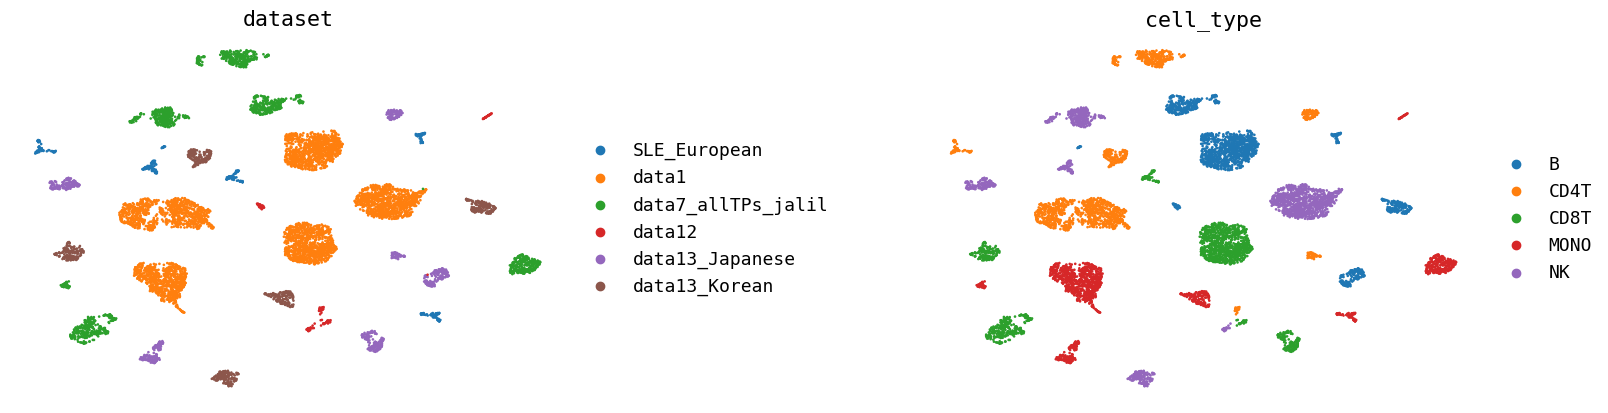

In [31]:
if True:
    wrapper_umap(latent_dict['latent_basal'])
    wrapper_umap(latent_dict['latent_corrected'])
    wrapper_umap(latent_dict['latent_after'])

100%|██████████| 8/8 [00:00<00:00, 130.96it/s]


Spearman correlation (per donor): 0.32, R² (per donor): -2.11


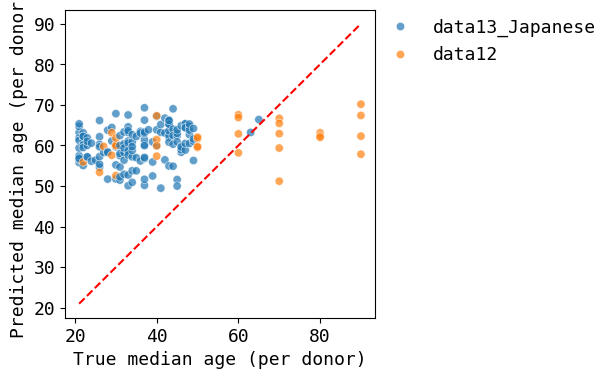

In [34]:
model.predict_age(adata_test, extend_categories=True)
age_predictor.evaluate(
    y_pred=adata_test.obs['age_predicted'], y_test=adata_test.obs['age'], 
    group_all=adata_test.obs['donor_age'], batch_all=adata_test.obs['dataset'])

Spearman correlation (per donor): 0.38, R² (per donor): -1.73


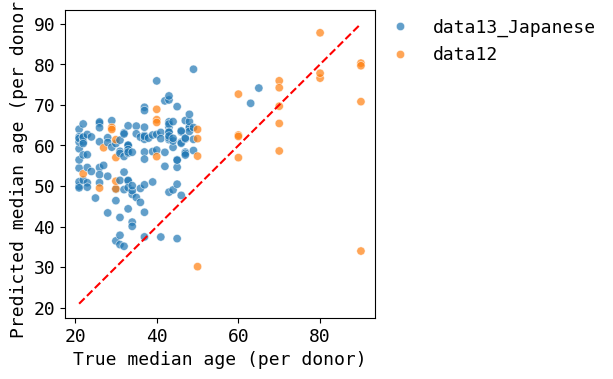

In [32]:
adata_corrected = latent_dict['latent_corrected']

if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
adata_corrected_test = obj.predict(adata_corrected_test)

In [ ]:
from ciim.src.clock.NN.helper import get_params
# model_params, trainer_params = get_params(data_type)
    
print("Testing mode activated.")


# model.setup_anndata_test(adata_test, is_count_data=True if data_type == 'sc' else False)


model.adata = adata_test
print(model.covars_encoder)

Testing mode activated.
Loading model ... 
INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


Loading training data ... 
Loading test data ... 
Extending embedding for test dataset ... 
covars_embeddings.dataset.weight: trainable
{'cell_type': {'B': 0, 'CD4T': 1, 'CD8T': 2, 'MONO': 3, 'NK': 4}, 'dataset': {'SLE_European': 0, 'data1': 1, 'data13_Korean': 2, 'data7_allTPs_jalil': 3, 'data13_Japanese': 4}}


### Check predicted age without correction

In [ ]:
adata_all = ad.concat([adata_train, adata_test], axis=0)
# cpa.CPA.wrapper_setup_anndata(adata_all, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)

NameError: name 'adata_train' is not defined

In [ ]:

latent_dict = model.get_latent_representation(adata=adata_all, extend_categories=True)
adata_corrected = latent_dict['latent_corrected']

if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
adata_corrected_test = obj.predict(adata_corrected_test)

Setting up data without cell type filtering.


  0%|          | 0/256 [00:00<?, ?it/s]


RuntimeError: Module tensors on multiple devices.

In [41]:
# model.adata_manager._registry

In [42]:
trainer_params = {
        "n_epochs_kl_warmup": None,
        "n_epochs_pretrain_ae": 1,
        "n_epochs_adv_warmup": 1,
        "n_epochs_mixup_warmup": 0,
        "mixup_alpha": 0.0,
        "use_batch_norm_adv": True,
        "use_layer_norm_adv": False,
        "dropout_rate_adv": 0.3,
        "reg_adv": 20,
        "pen_adv": 5,
        "lr": 0.0003,
        "wd": 0,
        "adv_lr": 0.0003,
        "adv_wd": 0,
        "adv_loss": "cce",
        "do_clip_grad": True,
        "gradient_clip_value": 1.0,
        "step_size_lr": 10,
    }
model.train(max_epochs=200,
        initial_training = False,
        use_gpu=True,
        batch_size=10,
        plan_kwargs=trainer_params,
        early_stopping_patience=5,
        check_val_every_n_epoch=20,
        save_path=save_path_test,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 20/200:  10%|▉         | 19/200 [00:18<03:29,  1.15s/it, v_num=1, recon=5.05e+3, adv_loss=3.33, acc_cell_type=0.234, acc_dataset=0.267]


Epoch 00019: cpa_metric reached. Module best state updated.


Epoch 60/200:  30%|██▉       | 59/200 [01:17<03:42,  1.58s/it, v_num=1, recon=4.33e+3, adv_loss=3.35, acc_cell_type=0.216, acc_dataset=0.254, val_recon=3.1e+3, val_r2_mean=0.934, val_KL=nan] 


Epoch 00059: cpa_metric reached. Module best state updated.


...

Epoch 200/200: 100%|█████████▉| 199/200 [04:19<00:00,  1.10it/s, v_num=1, recon=3.76e+3, adv_loss=3.34, acc_cell_type=0.257, acc_dataset=0.251, val_recon=2.52e+3, val_r2_mean=0.941, val_KL=nan]


Epoch 00199: cpa_metric reached. Module best state updated.


Epoch 200/200: 100%|██████████| 200/200 [04:20<00:00,  1.06it/s, v_num=1, recon=3.93e+3, adv_loss=3.37, acc_cell_type=0.255, acc_dataset=0.232, val_recon=2.5e+3, val_r2_mean=0.941, val_KL=nan] 

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [04:20<00:00,  1.30s/it, v_num=1, recon=3.93e+3, adv_loss=3.37, acc_cell_type=0.255, acc_dataset=0.232, val_recon=2.5e+3, val_r2_mean=0.941, val_KL=nan]


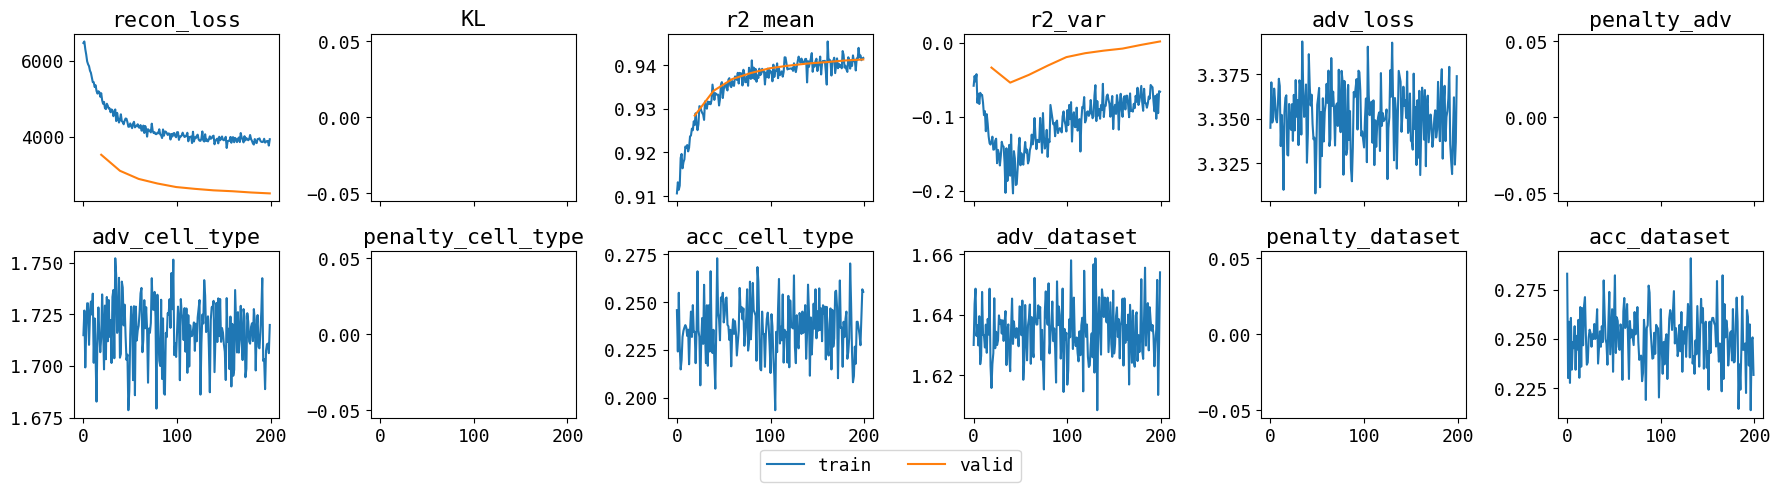

In [43]:
plot_history(model)

# Evaluate on test data

In [44]:
adata_train = format_data(train_datasets, cell_type_train, data_type)
adata_test = format_data(test_datasets, cell_type_train, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [ ]:
model_test = cpa.CPA.load(dir_path=save_path_test)
model_train = cpa.CPA.load(dir_path=save_path_train)
model_test.module.encoder.load_state_dict(model_train.module.encoder.state_dict())

INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_test/model.pt already downloaded                  


[rank: 0] Global seed set to 6977


INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


<All keys matched successfully>

In [46]:
import anndata as ad
adata_all = ad.concat([adata_train, adata_test], axis=0)
wrapper_setup_data(adata_all, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)
latent_dict = model_test.get_latent_representation(adata=adata_all, extend_categories=True)

Setting up data without cell type filtering.


100%|██████████| 256/256 [00:00<00:00, 263.73it/s]


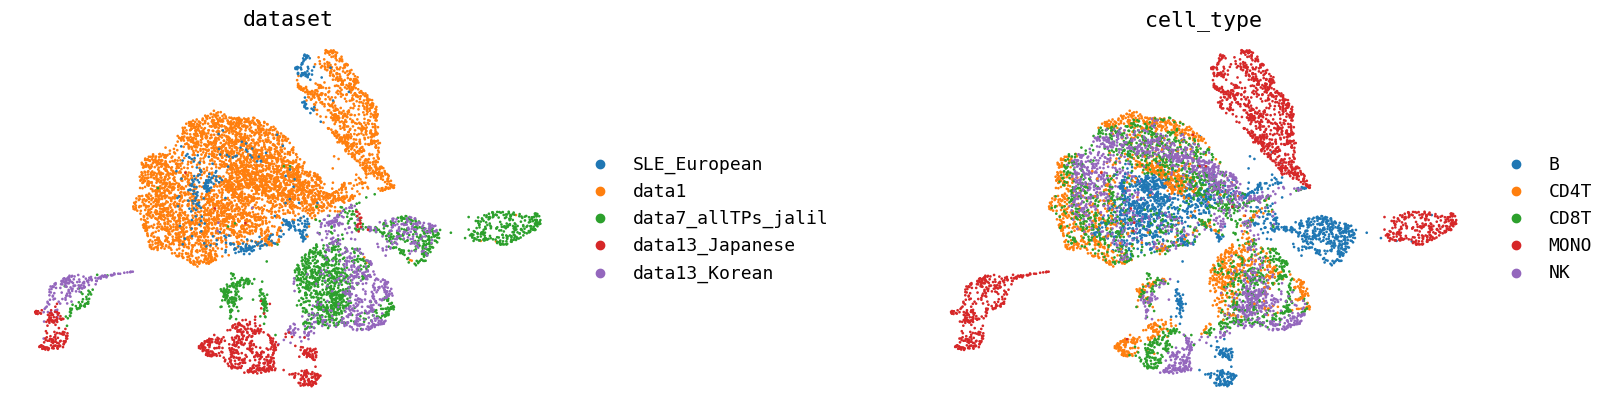

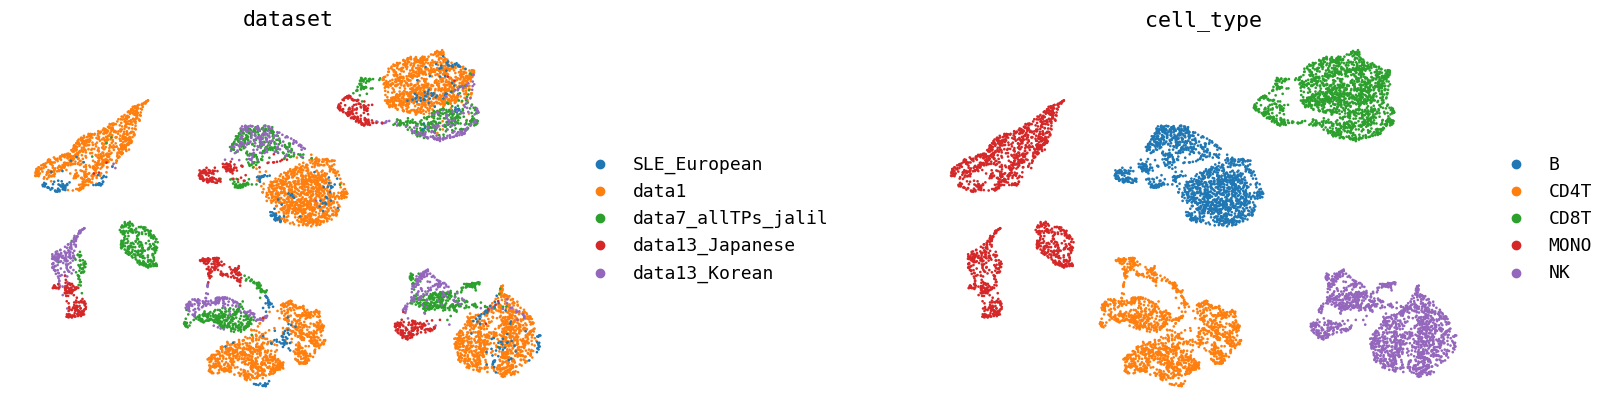

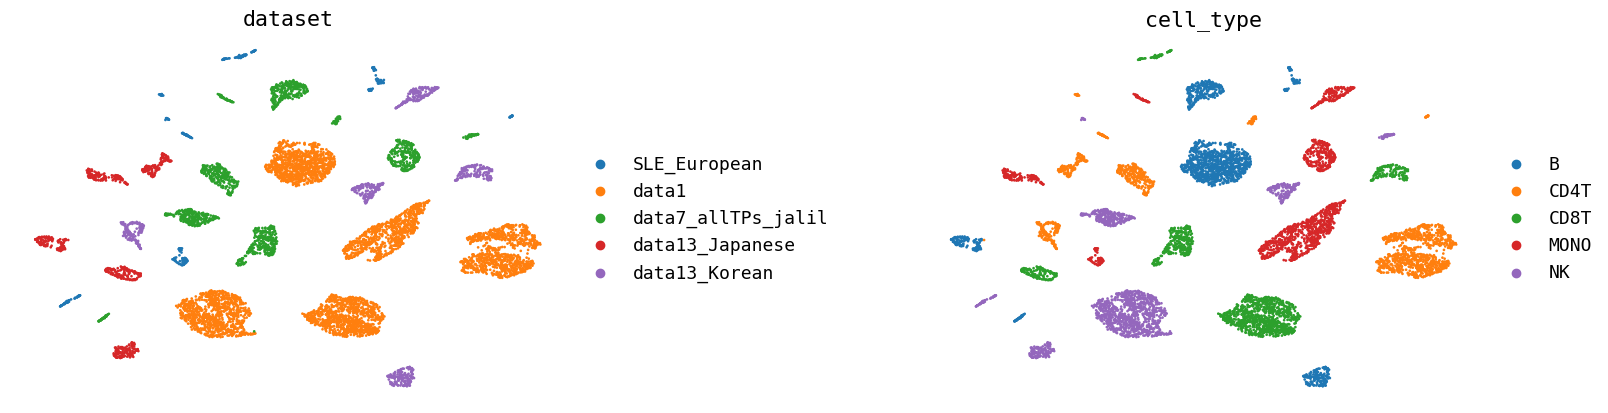

In [ ]:
wrapper_umap(latent_dict['latent_basal'])
wrapper_umap(latent_dict['latent_corrected'])
wrapper_umap(latent_dict['latent_after'])

Spearman correlation (per donor): 0.51, R² (per donor): 0.11


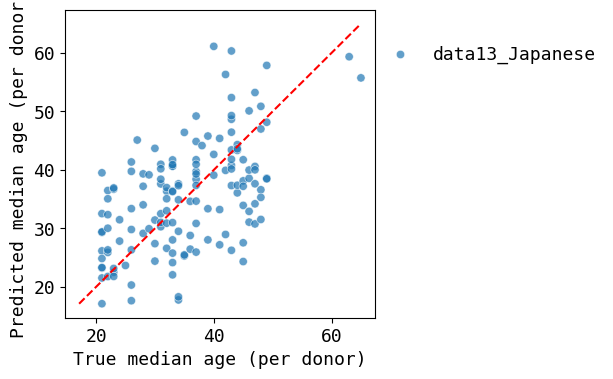

In [ ]:
adata_corrected = latent_dict['latent_corrected']

if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
adata_corrected_test = obj.predict(adata_corrected_test)

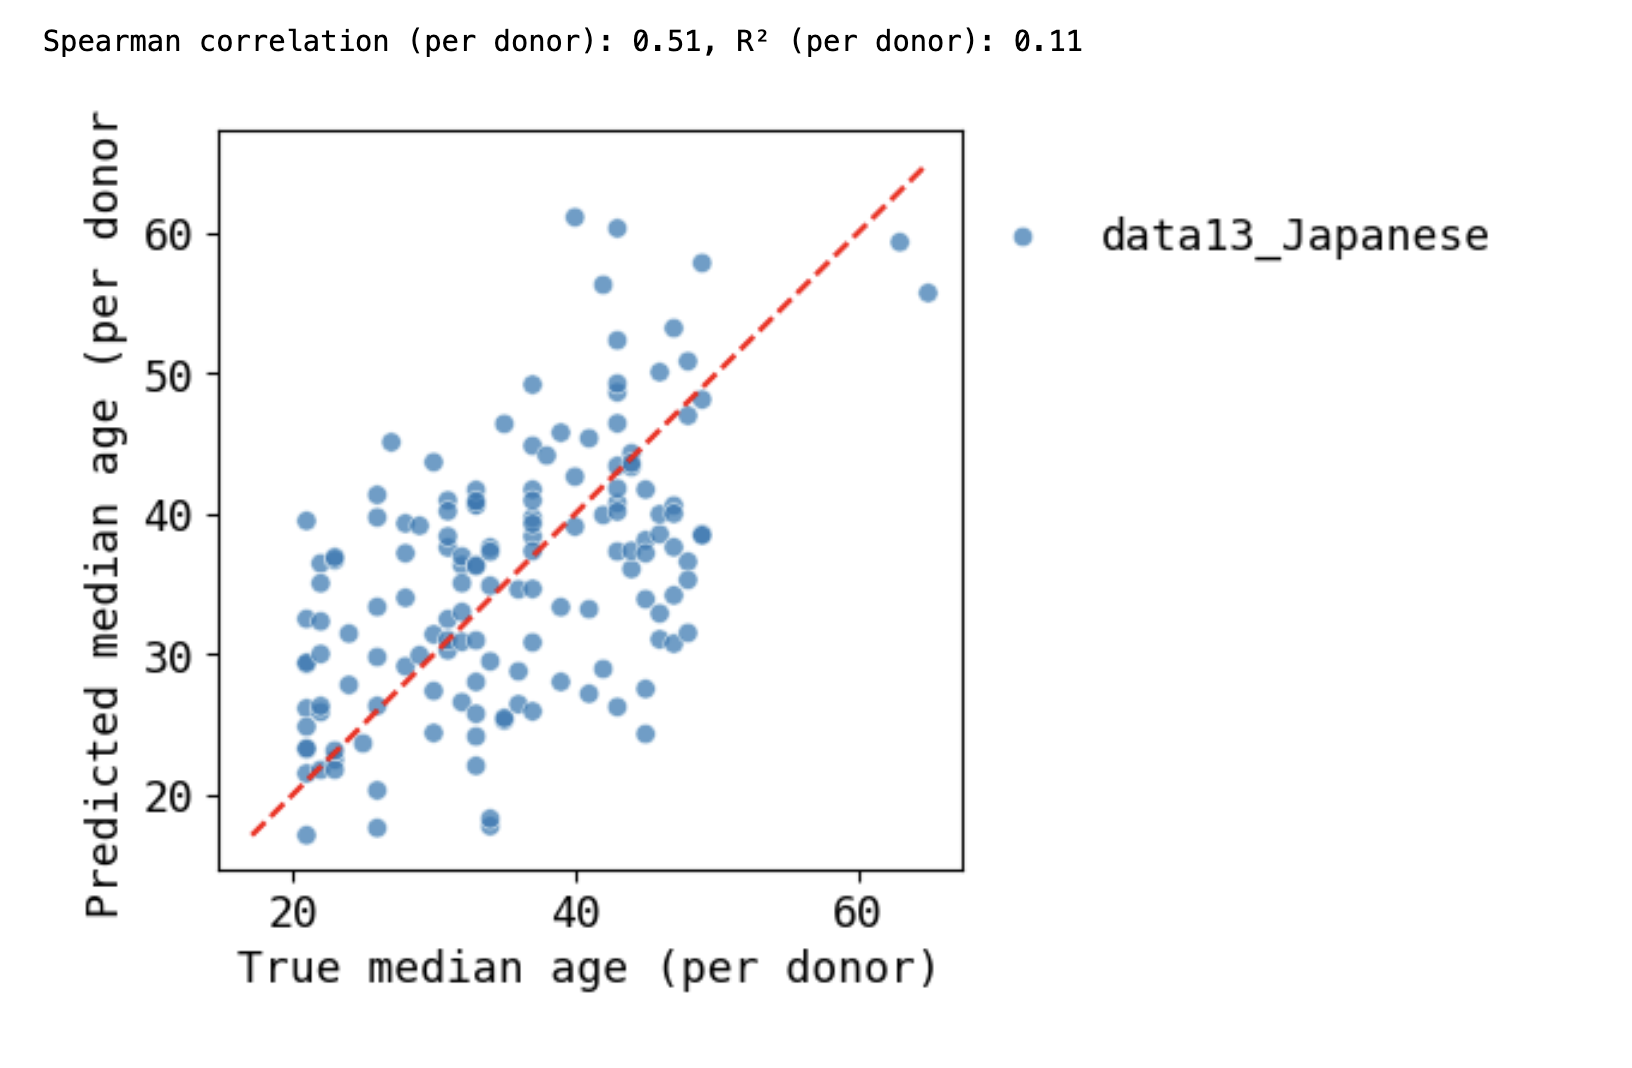

In [ ]:
# adata_corrected_test.obs
# r2_score(adata_corrected_test.obs['age'], adata_corrected_test.obs['predicted_age'])

In [50]:
aaa

NameError: name 'aaa' is not defined

# Sanity check

In [ ]:
model_test = cpa.CPA.load(dir_path=save_path_test)
model_train = cpa.CPA.load(dir_path=save_path_train)

INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_test/model.pt already downloaded                  


[rank: 0] Global seed set to 6977


INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


In [ ]:
torch.equal(
    model_train.module.covars_embeddings['dataset'].weight[:4],
    model_test.module.covars_embeddings['dataset'].weight[:4]
)

True

In [124]:
for (name1, p1), (name2, p2) in zip(
    model_train.module.encoder.named_parameters(),
    model_test.module.encoder.named_parameters()
):
    assert name1 == name2, f"Parameter name mismatch: {name1} vs {name2}"

    if torch.equal(p1, p2):
        print(f"{name1}: ✅ equal")
    else:
        diff = (p1 - p2).abs().max().item()
        print(f"{name1}: ❌ not equal (max abs diff = {diff:.6g})")

network.fc_layers.Layer 0.0.weight: ✅ equal
network.fc_layers.Layer 0.0.bias: ✅ equal
network.fc_layers.Layer 0.1.weight: ✅ equal
network.fc_layers.Layer 0.1.bias: ✅ equal
network.fc_layers.Layer 1.0.weight: ✅ equal
network.fc_layers.Layer 1.0.bias: ✅ equal
network.fc_layers.Layer 1.1.weight: ✅ equal
network.fc_layers.Layer 1.1.bias: ✅ equal
z.weight: ✅ equal
z.bias: ✅ equal


In [ ]:
for (name1, b1), (name2, b2) in zip(
    model_train.module.encoder.named_buffers(),
    model_test.module.encoder.named_buffers()
):
    assert name1 == name2, f"Buffer name mismatch: {name1} vs {name2}"
    if torch.equal(b1, b2):
        print(f"{name1}: ✅ equal")
    else:
        diff = (b1 - b2).abs().max().item()
        print(f"{name1}: ❌ not equal (max abs diff = {diff:.6g})")

network.fc_layers.Layer 0.1.running_mean: ✅ equal
network.fc_layers.Layer 0.1.running_var: ✅ equal
network.fc_layers.Layer 0.1.num_batches_tracked: ✅ equal
network.fc_layers.Layer 1.1.running_mean: ✅ equal
network.fc_layers.Layer 1.1.running_var: ✅ equal
network.fc_layers.Layer 1.1.num_batches_tracked: ✅ equal


In [95]:
skip_params = {
    "covars_embeddings.dataset.weight",  # full name for consistency
}

for (name1, p1), (name2, p2) in zip(
    model_train.module.named_parameters(),
    model_test.module.named_parameters()
):
    assert name1 == name2, f"Parameter order mismatch: {name1} vs {name2}"
    if name1 in skip_params:
        continue  # skip this one, you'll check manually later
    if not torch.equal(p1, p2):
        print(f"Mismatch found in {name1}")

In [9]:
wrapper_setup_data(adata_train, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)


Setting up data without cell type filtering.


In [ ]:
model_train.get_latent_representation(adata=adata_train, extend_categories=False)

  0%|          | 0/234 [00:00<?, ?it/s]

tensor([[ 0.3668,  0.5763, -0.3707,  ..., -1.0492,  0.3145,  0.6911],
        [ 0.9585, -0.2704, -1.4242,  ..., -1.2661, -0.9068,  0.9495],
        [ 0.4969,  0.6925, -0.3955,  ..., -1.2393, -0.1686,  0.9456],
        ...,
        [ 1.2864, -0.9844, -0.8084,  ..., -2.5286, -0.5195,  2.4228],
        [ 2.5081, -1.7721, -1.6863,  ..., -0.4522, -3.0076,  0.2014],
        [ 3.4733, -1.5788, -2.0648,  ..., -1.6358, -3.6092,  1.7245]],
       device='cuda:0')


SystemExit: 1

In [42]:
model_test.get_latent_representation(adata=adata_train, extend_categories=False)

  0%|          | 0/234 [00:00<?, ?it/s]

tensor([[ 0.3668,  0.5763, -0.3707,  ..., -1.0492,  0.3145,  0.6911],
        [ 0.9585, -0.2704, -1.4242,  ..., -1.2661, -0.9068,  0.9495],
        [ 0.4969,  0.6925, -0.3955,  ..., -1.2393, -0.1686,  0.9456],
        ...,
        [ 1.2864, -0.9844, -0.8084,  ..., -2.5286, -0.5195,  2.4228],
        [ 2.5081, -1.7721, -1.6863,  ..., -0.4522, -3.0076,  0.2014],
        [ 3.4733, -1.5788, -2.0648,  ..., -1.6358, -3.6092,  1.7245]],
       device='cuda:0')


SystemExit: 1